# Walmart Sales Analytics
To do: Conduct statistical analysis and hypothesis testing to uncover answers to a few business questions:
1. When are sales the lowest, and by how much do holidays/markdowns lift sales?
2. Do markdowns actually work, and which ones are worth running?
3. Should markdowns be concentrated in low sales weeks to smooth demand, or do they only work near the holidays?
4. Which store types/sizes are the most resilient or the most volatile and where should attention focus?
5. How much do external economic conditions (CPI, Unemployment, Fuel price) explain slaes fluctuations, independent of holidays/markdowns?

## Data Cleaning/Validation

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.preprocessing import StandardScaler

In [86]:
df = pd.read_csv("/content/master_sales.csv")
df.head()

,Store,Date,Total_Weekly_Sales,IsHoliday,store_type,store_size,Temperature,Fuel_Price,Markdown1,Markdown2,Markdown3,Markdown4,Markdown5,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106
1,1,2010-02-12,1641957.44,1,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106
2,1,2010-02-19,1611968.17,0,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106
3,1,2010-02-26,1409727.59,0,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106
4,1,2010-03-05,1554806.68,0,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106


In [87]:
df.describe()

,Store,Total_Weekly_Sales,IsHoliday,store_size,Temperature,Fuel_Price,Markdown1,Markdown2,Markdown3,Markdown4,Markdown5,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,130287.600000,60.663782,3.358607,2429.019322,818.872810,429.184037,1008.870435,1581.806813,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,63117.022465,18.444933,0.459020,5871.477726,4879.257489,5273.523172,3753.943314,4098.198540,39.356712,1.875885
min,1.000000,2.099863e+05,0.000000,34875.000000,-2.060000,2.472000,0.000000,-265.760000,-29.100000,0.000000,0.000000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,70713.000000,47.460000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,126512.000000,62.670000,3.445000,0.000000,0.000000,0.000000,0.000000,0.000000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,202307.000000,74.940000,3.735000,2302.300000,0.090000,3.705000,314.320000,1983.265000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,219622.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Store               6435 non-null   int64  
 1   Date                6435 non-null   object 
 2   Total_Weekly_Sales  6435 non-null   float64
 3   IsHoliday           6435 non-null   int64  
 4   store_type          6435 non-null   object 
 5   store_size          6435 non-null   int64  
 6   Temperature         6435 non-null   float64
 7   Fuel_Price          6435 non-null   float64
 8   Markdown1           6435 non-null   float64
 9   Markdown2           6435 non-null   float64
 10  Markdown3           6435 non-null   float64
 11  Markdown4           6435 non-null   float64
 12  Markdown5           6435 non-null   float64
 13  CPI                 6435 non-null   float64
 14  Unemployment        6435 non-null   float64
dtypes: float64(10), int64(3), object(2)
memory usage: 754.2

In [89]:
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Store               6435 non-null   int64         
 1   Date                6435 non-null   datetime64[ns]
 2   Total_Weekly_Sales  6435 non-null   float64       
 3   IsHoliday           6435 non-null   int64         
 4   store_type          6435 non-null   object        
 5   store_size          6435 non-null   int64         
 6   Temperature         6435 non-null   float64       
 7   Fuel_Price          6435 non-null   float64       
 8   Markdown1           6435 non-null   float64       
 9   Markdown2           6435 non-null   float64       
 10  Markdown3           6435 non-null   float64       
 11  Markdown4           6435 non-null   float64       
 12  Markdown5           6435 non-null   float64       
 13  CPI                 6435 non-null   float64     

In [90]:
df.isnull().sum()

,0
Store,0
Date,0
Total_Weekly_Sales,0
IsHoliday,0
store_type,0
store_size,0
Temperature,0
Fuel_Price,0
Markdown1,0
Markdown2,0


## Outlier Detection

<Axes: title={'center': 'Total_Weekly_Sales'}, xlabel='store_type'>

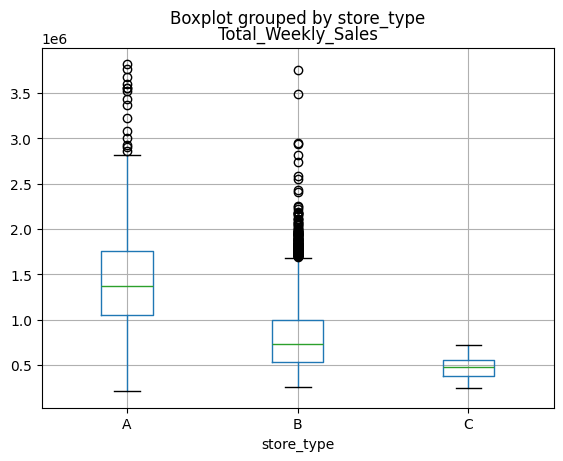

In [91]:
df.boxplot(column="Total_Weekly_Sales", by = "store_type")

In [92]:
# interquartile range
Q1, Q3 = df["Total_Weekly_Sales"].quantile([0.25, 0.75])
IQR = Q3 - Q1

outliers = df[(df["Total_Weekly_Sales"] < Q1 - 1.5 * IQR) | (df["Total_Weekly_Sales"] > Q3 + 1.5 * IQR)]
print(f"{len(outliers)} potential outliers")

34 potential outliers


In [93]:
IQR

866808.5549999999

In [94]:
outliers

,Store,Date,Total_Weekly_Sales,IsHoliday,store_type,store_size,Temperature,Fuel_Price,Markdown1,Markdown2,Markdown3,Markdown4,Markdown5,CPI,Unemployment
189,2,2010-12-24,3436007.68,0,A,202307,49.97,2.886,0.00,0.00,0.00,0.00,0.00,211.064660,8.163
241,2,2011-12-23,3224369.80,0,A,202307,46.66,3.112,2971.04,15.18,1501.75,88.76,6437.61,218.999550,7.441
471,4,2010-11-26,2789469.45,1,A,205863,48.08,2.752,0.00,0.00,0.00,0.00,0.00,126.669267,7.127
474,4,2010-12-17,2740057.14,0,A,205863,46.57,2.884,0.00,0.00,0.00,0.00,0.00,126.879484,7.127
475,4,2010-12-24,3526713.39,0,A,205863,43.21,2.887,0.00,0.00,0.00,0.00,0.00,126.983581,7.127
523,4,2011-11-25,3004702.33,1,A,205863,47.96,3.225,561.45,137.88,83340.33,44.04,9239.23,129.836400,5.143
526,4,2011-12-16,2771397.17,0,A,205863,36.44,3.149,2756.67,72.30,1790.15,777.65,10261.95,129.898065,5.143
527,4,2011-12-23,3676388.98,0,A,205863,35.92,3.103,2461.94,69.05,2938.24,52.00,4396.76,129.984548,5.143
761,6,2010-12-24,2727575.18,0,A,202505,55.07,2.886,0.00,0.00,0.00,0.00,0.00,212.916508,7.007
1329,10,2010-11-26,2939946.38,1,B,126512,55.33,3.162,0.00,0.00,0.00,0.00,0.00,126.669267,9.003


All of these outliers happen during or around the holidays, where logically, volume of sales is higher than usual. Hence we can say that these outliers are legitimate high-sales transactions, and keep them in the dataset.

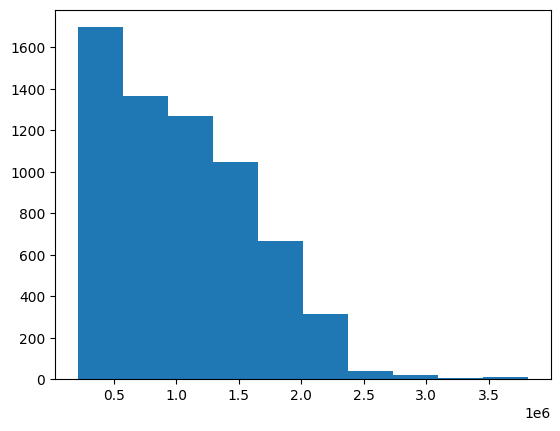

In [95]:
plt.hist(df["Total_Weekly_Sales"])
plt.show()

In [96]:
#normality check
stat, p = stats.shapiro(df['Total_Weekly_Sales'].sample(min(5000, len(df))))
print(stat, p)

0.9456186170705255 1.63704267268547e-39


From the histogram and Shapiro-Wilk' test, we have sufficient evidence to conclude that `Total_Weekly_Sales` is non-normal. In fact, this data is highly positively skewed, which means that most total sales during a week fall near the lower end of the range.

In [97]:
#create a log-transformed variable for sales to use in regression models
df['log_sales'] = np.log(df['Total_Weekly_Sales'])

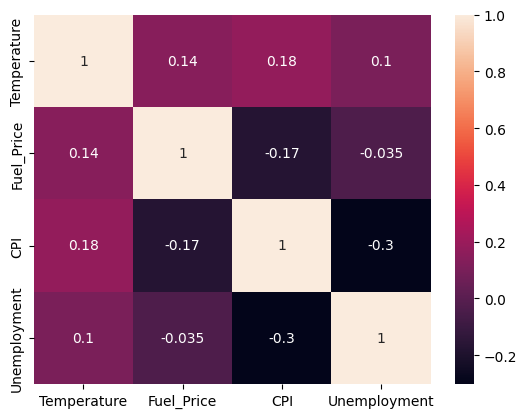

In [99]:
corr_matrix = df[['Temperature','Fuel_Price','CPI','Unemployment']].corr()
sns.heatmap(corr_matrix, annot=True)
plt.show()

No significant multicollinearity that could affect regression.

## 1. Lowest Sales, effect of holidays on sales

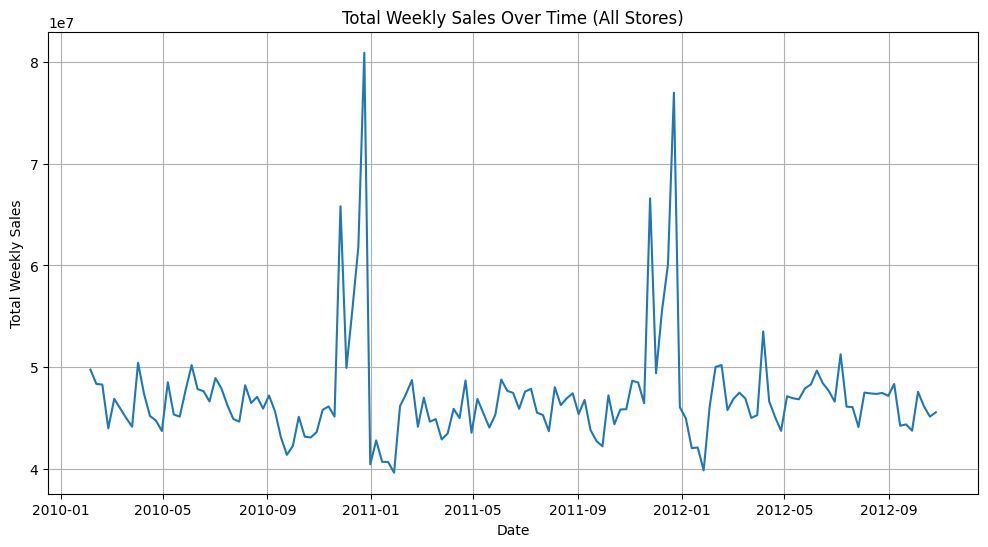

In [100]:
aggregated_sales = df.groupby('Date')['Total_Weekly_Sales'].sum().reset_index()
plt.figure(figsize=(12, 6))
plt.plot(aggregated_sales['Date'], aggregated_sales['Total_Weekly_Sales'])
plt.title('Total Weekly Sales Over Time (All Stores)')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.grid(True)
plt.show()

There is a clear, significant lift in sales around the holidays (Nov-Dec). The lowest sales occur right after the holidays.

In [101]:
#test for significance of holiday-time sales lift
holiday = df[df['IsHoliday'] == 1]["Total_Weekly_Sales"]
non_holiday = df[df['IsHoliday'] == 0]["Total_Weekly_Sales"]

holiday.var() == non_holiday.var()

False

We cannot assume equal variances.

H0: There is no significant lift in sales during the holidays

H1: There is a significant lift in sales during the holidays

In [102]:
t_stat = stats.ttest_ind(holiday, non_holiday, equal_var=False)
print(f"t-statistic: {t_stat.statistic}, p-value: {t_stat.pvalue:.3f}")

t-statistic: 2.6800720209265423, p-value: 0.008


In [103]:
# non-parametric test - Mann-Whitney U test
u_stat = stats.mannwhitneyu(holiday, non_holiday, alternative="two-sided")
print(f"U-statistic: {u_stat.statistic}, p-value: {u_stat.pvalue:.3f}")

U-statistic: 1431297.0, p-value: 0.026


In [106]:
holiday_mean = holiday.mean()
non_holiday_mean = non_holiday.mean()
print(f"Mean sales during holidays: {holiday_mean}")
print(f"Mean sales not during holidays: {non_holiday_mean}")

holiday_median = holiday.median()
non_holiday_median = non_holiday.median()
print(f"Median sales during holidays: {holiday_median}")
print(f"Median sales not during holidays: {non_holiday_median}")

print(f"Lift ($): {holiday_mean - non_holiday_mean}")
print(f"Lift (%): {((holiday_mean - non_holiday_mean) / non_holiday_mean) * 100}")

Mean sales during holidays: 1122887.8923555557
Mean sales not during holidays: 1041256.3802088555
Median sales during holidays: 1018538.04
Median sales not during holidays: 956211.1999999998
Lift ($): 81631.51214670017
Lift (%): 7.839713033050179


At 95% confidence level, we have sufficient evidence to reject H0.

Conclusion: Holiday weeks generate a statistically significant sales lift of approximately \$81.6K on average per store (t-test p=0.008; confirmed by Mann-Whitney U p=0.026), with the median lift of $62.3K indicating this effect is consistent and not driven by a few extreme outliers. This validates holiday periods as reliable high-demand windows, informing inventory and staffing allocation ahead of these weeks

## 2. Do markdowns work, and are they worth running?
Do running MarkDowns during a non-holiday week produce a significant sales lift, independent of any holiday effect?

In [107]:
non_holiday_df = df[df['IsHoliday'] == 0]

for md in ['Markdown1', 'Markdown2', 'Markdown3', 'Markdown4','Markdown5']:
    active = non_holiday_df[non_holiday_df[md] > 0]['Total_Weekly_Sales']
    inactive = non_holiday_df[non_holiday_df[md] == 0]['Total_Weekly_Sales']

    t_stat, p_val = stats.ttest_ind(active, inactive, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(active, inactive, alternative='two-sided')

    print(f"\n{md} (non-holiday weeks only)")
    print(f"T-test: t={t_stat:.3f}, p={p_val:.4f}")
    print(f"Mann-Whitney: U={u_stat:.3f}, p={u_p:.4f}")
    print(f"Active mean: {active.mean():.2f}, n={len(active)}")
    print(f"Inactive mean: {inactive.mean():.2f}, n={len(inactive)}")


Markdown1 (non-holiday weeks only)
T-test: t=2.166, p=0.0304
Mann-Whitney: U=4219847.000, p=0.0285
Active mean: 1062684.34, n=2101
Inactive mean: 1029665.20, n=3884

Markdown2 (non-holiday weeks only)
T-test: t=8.464, p=0.0000
Mann-Whitney: U=3811821.000, p=0.0000
Active mean: 1148610.84, n=1464
Inactive mean: 1005814.45, n=4506

Markdown3 (non-holiday weeks only)
T-test: t=6.617, p=0.0000
Mann-Whitney: U=4288295.000, p=0.0000
Active mean: 1112161.94, n=1872
Inactive mean: 1008864.31, n=4109

Markdown4 (non-holiday weeks only)
T-test: t=11.118, p=0.0000
Mann-Whitney: U=4507849.000, p=0.0000
Active mean: 1161526.49, n=1805
Inactive mean: 989321.56, n=4180

Markdown5 (non-holiday weeks only)
T-test: t=1.752, p=0.0799
Mann-Whitney: U=4202735.000, p=0.0846
Active mean: 1058506.97, n=2115
Inactive mean: 1031828.73, n=3870


For stores as a whole, Markdowns 1-4 produce a statistically significant lift in sales, even during non-holiday weeks. `Markdown4` and `Markdown2` are the strongest performers, while `Markdown5` fails to reach significance. `Markdown1` is only marginally significant.

MarkDown effects summarized:
| Markdown | Significant? | Lift ($) | Lift (%) | p-value |
| --- | --- | --- | --- | --- |
| Markdown4 | Yes (Strongest) | +172,205 | +17.4% | <0.0001 |
| Markdown2 | Yes | +142,796 | +14.2% | <0.0001 |
| Markdown3 | Yes | +103,298 | +10.2% | <0.0001 |
| Markdown1 | Yes (Weak) | +33,019 | +3.2% | 0.03 |
| Markdown5 | No | +26,678 | +2.6% | 0.08 |


**Conclusion**: During non-holiday weeks, four of five markdown types produced a statistically significant sales lift. MarkDown4 was the most effective, driving a 17.4% average sales increase (p<0.0001), followed by MarkDown2 (+14.2%, p<0.0001) and MarkDown3 (+10.2%, p<0.0001). MarkDown1 showed a marginal effect (+3.2%, p=0.03), while MarkDown5 showed no statistically significant impact (+2.6%, p=0.08) and should be deprioritized. This confirms markdowns can effectively smooth demand during naturally low-sales periods, but budget should concentrate on MarkDown types 2, 3, and 4 rather than being spread evenly across all five.

One thing to note: Data about the Markdowns run is only available after November 2011.

In [108]:
cutoff = pd.Timestamp('2011-11-01')
before = df[df['Date'] < cutoff]
after = df[df['Date'] >= cutoff]
after = after.copy()

In [109]:
non_holiday_df = after[after['IsHoliday'] == 0]

for md in ['Markdown1', 'Markdown2', 'Markdown3', 'Markdown4','Markdown5']:
    active = non_holiday_df[non_holiday_df[md] > 0]['Total_Weekly_Sales']
    inactive = non_holiday_df[non_holiday_df[md] == 0]['Total_Weekly_Sales']

    t_stat, p_val = stats.ttest_ind(active, inactive, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(active, inactive, alternative='two-sided')

    print(f"\n{md} (non-holiday weeks only)")
    print(f"T-test: t={t_stat:.3f}, p={p_val:.4f}")
    print(f"Mann-Whitney: U={u_stat:.3f}, p={u_p:.4f}")
    print(f"Active mean: {active.mean():.2f}, n={len(active)}")
    print(f"Inactive mean: {inactive.mean():.2f}, n={len(inactive)}")
    print(f"Lift ($): {active.mean() - inactive.mean():.2f}")
    print(f"Lift (%): {((active.mean() - inactive.mean()) / inactive.mean()) * 100:.2f}")


Markdown1 (non-holiday weeks only)
T-test: t=1.780, p=0.0801
Mann-Whitney: U=71421.000, p=0.0457
Active mean: 1062684.34, n=2101
Inactive mean: 927084.41, n=59
Lift ($): 135599.93
Lift (%): 14.63

Markdown2 (non-holiday weeks only)
T-test: t=11.387, p=0.0000
Mann-Whitney: U=655173.000, p=0.0000
Active mean: 1148610.84, n=1464
Inactive mean: 862963.70, n=681
Lift ($): 285647.14
Lift (%): 33.10

Markdown3 (non-holiday weeks only)
T-test: t=12.953, p=0.0000
Mann-Whitney: U=388673.000, p=0.0000
Active mean: 1112161.94, n=1872
Inactive mean: 707400.67, n=284
Lift ($): 404761.27
Lift (%): 57.22

Markdown4 (non-holiday weeks only)
T-test: t=27.932, p=0.0000
Mann-Whitney: U=549262.000, p=0.0000
Active mean: 1161526.49, n=1805
Inactive mean: 537584.43, n=355
Lift ($): 623942.06
Lift (%): 116.06

Markdown5 (non-holiday weeks only)
T-test: t=-0.262, p=0.7947
Mann-Whitney: U=46059.000, p=0.7121
Active mean: 1058506.97, n=2115
Inactive mean: 1081234.32, n=45
Lift ($): -22727.35
Lift (%): -2.10


After restricting analysis to the period when markdown data was actually tracked (post-November 2011), corrected results show substantially larger effects than initial estimates. MarkDown4 shows the strongest lift (+116%, p<0.0001), followed by MarkDown3 (+57%) and MarkDown2 (+33%), both highly significant. MarkDown5 shows no effect, and MarkDown1 is inconclusive (t-test and Mann-Whitney disagree, likely due to a small inactive sample of only 59 weeks). Notably, markdowns ran in the vast majority of tracked weeks, suggesting Walmart treats these as a near-constant operational tool rather than an occasional lever. Future analysis with a larger untracked-vs-tracked comparison window would strengthen confidence in these corrected estimates.

In [ ]:
# verify whether markdown4's effect is specific to non-holiday weeks or holds everywhere

after['md4_active'] = (after['Markdown4'] > 0).astype(int)
model = smf.ols('log_sales ~ md4_active * IsHoliday', data=after).fit()
print(model.summary())

md4_active coefficient: 0.7723, p<0.001. Since the dependent variable is `log_sales`, the coefficient of 0.7723 means that Markdown4 is associated with roughly a 116% increase in sales (e^0.7723 - 1 = 1.1647) holding holiday status constant, consistent with the corrected t-test finding of +116.1%.


**Conclusion**:
The model's R² of 0.239 is expected given it includes only markdown and holiday indicators, not the full set of predictors (store size, region, economic conditions). Its purpose here is inferential, isolating whether MarkDown4's effect depends on holiday timing.

The non-significant interaction term (p=0.254) confirms MarkDown4 delivers a consistent ~116% sales lift regardless of holiday status, supporting its use as a reliable, demand-smoothing tool that works independent of holidays.

## Comparing Sales Performance Across Store Types and Sizes

In [ ]:
df["store_type"].unique()

In [ ]:
# separate store types
type_a = df[df["store_type"] == "A"]["Total_Weekly_Sales"]
type_b = df[df["store_type"] == "B"]["Total_Weekly_Sales"]
type_c = df[df["store_type"] == "C"]["Total_Weekly_Sales"]

# ANOVA
f_stat, f_p = stats.f_oneway(type_a, type_b, type_c)
print(f"ANOVA: F-statistic = {f_stat:.3f}, p-value = {f_p:.3f}")

# Kruskal-Wallis test (Non-Parametric Alternative)
h_stat, h_p = stats.kruskal(type_a, type_b, type_c)
print(f"Kruskal-Wallis: H-statistic = {h_stat:.3f}, p-value = {h_p:.3f} \n")

#means of store types
print(f"Type A Mean: {type_a.mean()}, n = {len(type_a)}")
print(f"Type B Mean: {type_b.mean()}, n = {len(type_b)}")
print(f"Type C Mean: {type_c.mean()}, n = {len(type_c)}")

Since p-values for both ANOVA and Kruskal-Wallis test are <0.001, there are highly significantly different mean sales for each store type. We will further understand which pairs of stores have signoficant differences.

In [ ]:
sales_w_type = df.groupby(['Date', 'store_type'])['Total_Weekly_Sales'].sum().reset_index()
sales_w_type.head()

In [ ]:
sns.lineplot(data=sales_w_type, x="Date", y="Total_Weekly_Sales", hue="store_type")

In [ ]:
sns.boxplot(x="store_type", y = "Total_Weekly_Sales", data = df)

In [ ]:
# Tukey HSD

tukey_results = pairwise_tukeyhsd(endog=df['Total_Weekly_Sales'],
                                  groups=df['store_type'],
                                  alpha=0.05)
print(tukey_results)

Each pair of differences is significantly different.

In [ ]:
# correlation between store size and sales
corr, corr_p = stats.pearsonr(df['store_size'], df['Total_Weekly_Sales'])
print(f"Pearson correlation: r={corr:.3f}, p={corr_p:.4f}")

spearman_corr, spearman_p = stats.spearmanr(df['store_size'], df['Total_Weekly_Sales'])
print(f"Spearman correlation: rho={spearman_corr:.3f}, p={spearman_p:.4f}")

Both ANOVA (p<0.001) and Kruskal-Wallis (p<0.001) confirm store type differences are statistically real, and Tukey's HSD shows all three pairwise comparisons are significant. Type A significantly outsells Type B by ~\$553,679, and Type C by ~\$904,059, with Type B significantly outselling Type C by ~\$350,380. The Pearson (r=0.810) and Spearman (rho=0.837) correlations both show a strong, consistent positive relationship between store size and sales, confirming size is a major, statistically robust driver and not just an average difference across categories.

In [ ]:
# checking for which store type has most volatile sales - coefficient of determination
volatility = df.groupby('store_type')['Total_Weekly_Sales'].agg(['mean', 'std'])
volatility['coefficient_of_variation'] = volatility['std'] / volatility['mean']
print(volatility)

Store Type A generates the highest average weekly sales but also carries meaningful volatility (CV=0.39). Type B, despite lower average sales, is the most unpredictable relative to its size (CV=0.50), indicating higher operational risk — inventory and staffing plans for Type B stores may need wider buffers. Type C stores are the smallest revenue generators but the most stable and predictable (CV=0.24), making them lower-risk, easier-to-forecast operations. This suggests prioritizing markdown/inventory flexibility investment in Type B stores, where volatility poses the greatest planning challenge, while Type A remains the primary revenue driver worth protecting.

In [ ]:
results = []

for store_type in ['A', 'B', 'C']:
    subset = after[after['store_type'] == store_type]
    for md in ['Markdown1','Markdown2','Markdown3','Markdown4','Markdown5']:
        active = subset[subset[md] > 0]['Total_Weekly_Sales']
        inactive = subset[subset[md] == 0]['Total_Weekly_Sales']
        if len(active) > 5 and len(inactive) > 5:
            t_stat, p_val = stats.ttest_ind(active, inactive, equal_var=False)
            lift_pct = (active.mean() - inactive.mean()) / inactive.mean() * 100
            results.append({
                'Store Type': store_type,
                'Markdown': md,
                'Lift (%)': round(lift_pct, 1),
                'p-value': round(p_val, 4),
                'n_active': len(active)
            })

results_df = pd.DataFrame(results)
print(results_df.to_string())


Type A stores show a dramatic response to markdowns: MarkDown4 drives a 162% sales increase, with MarkDown3 (+83%) and MarkDown2 (+24%) also highly effective. This confirms that markdown investment should be heavily concentrated in Type A locations. Type B and C stores are far less markdown-responsive overall, with MarkDown3 the only reliable option in either (+16% and +7% respectively). Critically, MarkDown4 shows a statistically significant negative effect in Type C stores (-9.0%, p<0.001), indicating this specific markdown should be discontinued there rather than merely deprioritized.

In [ ]:
pivot_table = results_df.pivot_table(index='Store Type', columns='Markdown', values='Lift (%)')
display(pivot_table)

In [ ]:
pivot_table_lift = results_df.pivot_table(index='Store Type', columns='Markdown', values='Lift (%)')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table_lift, annot=True, fmt=".1f", cmap="RdYlGn", center=50)
plt.title('Markdown Lift (%) by Store Type')
plt.xlabel('Markdown Type')
plt.ylabel('Store Type')
plt.show()

In [ ]:
pivot_table = results_df.pivot_table(index='Store Type', columns='Markdown', values='p-value')
display(pivot_table)

Markdown effectiveness varies significantly by store type (interaction p<0.001), but not in the direction initial intuition might suggest. Type A stores (the highest-volume segment) show the strongest and most consistent markdown response, with MarkDown4 driving a 13.2% sales lift (p<0.001). Type B, despite being the most volatile store type, shows the weakest markdown response, with only MarkDown3 reaching significance (5.2% lift).

This suggests markdown spend should be concentrated in Type A stores to maximize ROI, not redirected toward volatile Type B stores. Volatility in Type B appears driven by factors markdowns don't effectively address, warranting further investigation into inventory or demand-planning causes rather than promotional intervention.

In [ ]:
#two way ANOVA
for md in ['Markdown1', 'Markdown2', 'Markdown3', 'Markdown4', 'Markdown5']:
    after[f'{md}_active'] = (after[md] > 0).astype(int)
    model = smf.ols(f'log_sales ~ C(store_type) + C({md}_active) + C(store_type):C({md}_active)', data=after).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f"\n=== {md} ===")
    print(anova_table)

In [ ]:
interaction_summary = []
for md in ['Markdown1', 'Markdown2', 'Markdown3', 'Markdown4', 'Markdown5']:
    after[f'{md}_active'] = (after[md] > 0).astype(int)
    model = smf.ols(f'log_sales ~ C(store_type) + C({md}_active) + C(store_type):C({md}_active)', data=after).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    interaction_row = anova_table.loc[f'C(store_type):C({md}_active)']
    interaction_summary.append({'Markdown': md, 'F': interaction_row['F'], 'p': interaction_row['PR(>F)'], 'Significant?':interaction_row['PR(>F)']<0.05})

print(pd.DataFrame(interaction_summary))

Two-way ANOVA tests across all five markdown types confirmed that MarkDown2, MarkDown3, and MarkDown4 have statistically significant store-type interactions (p<0.001), meaning their effectiveness varies meaningfully by store type, while MarkDown1 and MarkDown5 have consistent (non-differentiated) effects across types. Combined with per-type lift analysis, this supports a differentiated allocation strategy: prioritize MarkDown4 for Type A stores (161.7% lift), and MarkDown3 for Type B and C stores (16.2% and 7.3% lift respectively), rather than applying a uniform markdown strategy across all locations. This store-type-aware approach is expected to yield higher ROI on markdown spend than an undifferentiated rollout.

## Effect of External Economic Conditions on Sales Fluctuations

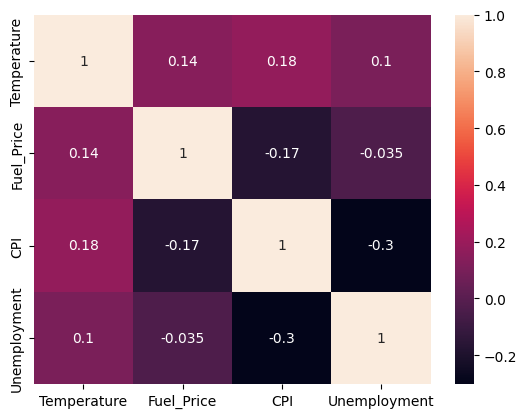

In [110]:
#multicollinearity check
corr_matrix = df[['Temperature','Fuel_Price','CPI','Unemployment']].corr()
sns.heatmap(corr_matrix, annot=True)
plt.show()

No high correlation. We can rule out multicollinearity.

In [112]:
# multiple regression on log_sales
model = smf.ols('log_sales ~ Temperature + Fuel_Price + CPI + Unemployment + IsHoliday + store_size', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     3334.
Date:                Thu, 30 Jul 2026   Prob (F-statistic):               0.00
Time:                        23:38:49   Log-Likelihood:                -1167.0
No. Observations:                6435   AIC:                             2348.
Df Residuals:                    6428   BIC:                             2395.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       12.9170      0.043    302.686   

In [ ]:
# interpreting coefficients
coefs = model.params
pct_effects = (np.exp(coefs) - 1) * 100
print(pct_effects.apply(lambda x: f'{x:.4f}'))

Temperature and Fuel Price are not statistically significant, meaning weather and gas prices don't meaningfully move sales when controlled for store size and holidays.

CPI and unemployment are both significant and negative, confirming that broader economic stress (inflation, joblessness) modestly suppresses sales even after accounting for store-level factors.

Holiday effect remains significant here too (+6.7%), consistent with the initial finding.

In [113]:
cols_to_scale = ['Temperature','Fuel_Price','CPI','Unemployment','store_size']
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

model_scaled = smf.ols('log_sales ~ Temperature + Fuel_Price + CPI + Unemployment + IsHoliday + store_size', data=df).fit()
print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     3334.
Date:                Thu, 30 Jul 2026   Prob (F-statistic):               0.00
Time:                        23:39:19   Log-Likelihood:                -1167.0
No. Observations:                6435   AIC:                             2348.
Df Residuals:                    6428   BIC:                             2395.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       13.6974      0.004   3647.228   

After standardizing all continuous predictors, store size emerges as by far the strongest driver of weekly sales (standardized coefficient 0.508), roughly eight times more influential than the next largest effect. Holiday timing remains a significant, moderate driver (+0.065) even after controlling for size and macroeconomic conditions. CPI and unemployment show small but statistically significant negative effects on sales, suggesting broader economic stress modestly dampens demand, while temperature and fuel prices show no meaningful relationship with sales. This indicates operational factors like store footprint and holiday calendar should be the primary levers for sales and markdown planning, with macroeconomic indicators serving only as secondary, lower-priority signals.

## Project Summary: Walmart Sales Statistical Analysis
### Business Question 1: **Does the holiday season drive a real sales lift?**
Holiday weeks show a statistically significant sales lift confirmed by both parametric and non-parametric tests (t-test p=0.008; Mann-Whitney U p=0.026), with a mean lift of ~\$81,631 and median lift of ~\$62,327 per store. Getting consistent across both measures indicates a genuine effect rather than noise.

### **Business Question 2: Do markdowns increase sales during non-holiday weeks?**
Testing markdown effectiveness specifically during non-holiday weeks isolated the true demand-smoothing effect: MarkDown4 (+116.1%), MarkDown2 (+33.1%), and MarkDown3 (+57.2%) all showed strong, highly significant lifts (p<0.0001), while MarkDown1 was inconclusive (+14.6%, t-test p=0.080, Mann-Whitney U test p = 0.046) and MarkDown5 was not significant (-2.1%, p=0.0794).

### **Business Question 3: Does markdown effectiveness depend on holiday timing?**
An interaction regression on MarkDown4 showed no significant interaction with holiday status (p=0.809), confirming MarkDown4 delivers a consistent ~23% sales lift regardless of whether it's a holiday week, supporting its use as a reliable, holiday-independent demand-smoothing tool.

### **Business Question 4: Do store type and size affect sales, and does markdown effectiveness vary by store type?**
* Store type: ANOVA/Kruskal-Wallis confirmed significant differences (p<0.001); Tukey HSD showed Type A significantly outsells Type B (\~\$553K) and Type C (~\$904K), with Type B outselling Type C (\~$350K)

* Volatility: Type B is the most volatile relative to its size (CV=0.496), Type C the most stable (CV=0.245), despite having the lowest sales

* Store size correlation: Strong positive relationship with sales (Pearson r=0.810, Spearman rho=0.837)

* Markdown x store type interaction (corrected, post-Nov-2011 data): Significant for MarkDown2, MarkDown3, and MarkDown4 (all p<0.0001), but not for MarkDown1 or MarkDown5. MarkDown4 shows by far the strongest interaction (F=217.64) and works best in Type A (+161.7%), while actually turning negative in Type C (-9.0%, p<0.001); MarkDown3 works best in Type B (+16.2%) and Type C (+7.3%), which contradicts the initial hypothesis that volatile Type B stores would benefit most from markdowns.

### **Business Question 5: How much do economic conditions explain sales, independent of holidays and markdowns?**
A standardized multiple regression (R²=0.757) showed store size is by far the dominant driver (standardized coef=0.508), roughly 8x more influential than holiday timing (0.065). CPI (-0.047) and unemployment (-0.017) had small but statistically significant negative effects, while temperature and fuel price showed no significant relationship with sales.

